# ANN(Artificial Neural Network) 실습문제

## 심화 실습문제

### 실습문제 1. 상관계수(Correlation Coefficient) 분석


1. 상관계수(Correlation Coefficient)의 의미를 설명하시오.
2. 상관계수 값의 범위를 작성하시오.
3. 상관계수가 0.95인 경우 모델 성능을 평가하시오.
4. 상관계수와 MSE의 차이점을 설명하시오.

In [ ]:
'''
상관계수는 두 변수간의 관계를 의미한다.  -1~1값으로 값이 높을수록 양의 관계가 존재한다.

-1 ~ 1

아주 강한 양의 상관관계가 있다. 다만 모델성능과는 관계가 미흡이기에 아직 평가할 수 없다. 

상관계수는 예측값이 실제값을 얼마나 잘 따라가고 있는지를 평가하하는것이고
MSE 평균제곱오차. 실제값과 예측값 차이를 제곱해서 평균함 값이다. 예측값과 실제값의 오차가 얼마나 적느냐를 보는것. 값이 0에 가까울 수록 좋은 성능을 의미한다고 한다.  
만일 문제 3에 MSE가 0이 가까웠다면 성능이 좋다고 말할 수가 있을듯 하다. 
'''

In [58]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from google.colab import drive



# 시드고정.
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터불러오기
drive.mount('/content/drive')
CSV_PATH = "/content/drive/MyDrive/data/concrete_stg.csv"
concrete_stg = pd.read_csv(CSV_PATH)
feature_cols = ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age']
target_col = 'strength'

# 정규화.
def min_max_normalize(series):
    min_value = series.min()
    max_value = series.max()
    if max_value == min_value:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_value) / (max_value - min_value)
concrete_stg_norm = concrete_stg.apply(min_max_normalize)

# 훈련/테스트 데이터
train_df = concrete_stg_norm.iloc[:780].copy()
test_df = concrete_stg_norm.iloc[780:1030].copy()

# 형 변환 및 tensor 변환
X_train_np = train_df[feature_cols].values.astype(np.float32)
y_train_np = train_df[target_col].values.astype(np.float32).reshape(-1, 1)
X_test_np = test_df[feature_cols].values.astype(np.float32)
y_test_np = test_df[target_col].values.astype(np.float32).reshape(-1, 1)
X_train = torch.tensor(X_train_np).to(device)
y_train = torch.tensor(y_train_np).to(device)
X_test = torch.tensor(X_test_np).to(device)
y_test = torch.tensor(y_test_np).to(device)

# 모델 클래스
class ConcreteANN(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation='sigmoid'):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'softplus':
                layers.append(nn.Softplus())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'relu':
                layers.append(nn.ReLU())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 실습문제 2. 과적합(Overfitting) 분석

1. 과적합(Overfitting)의 의미를 설명하시오.
2. 은닉노드를 50개 이상으로 증가시켰을 때 발생할 수 있는 문제를 설명하시오.
3. 과적합을 방지하는 방법을 3가지 이상 작성하시오.

In [ ]:
''' 
과적합이란 모델이 과한 학습으로 예측값 정확도가 높으나 테스트 데이터에서는 정확도가 낮은 현상을 의미한다.

은닉노드가 50개 이상이 되면 과적합이 발생할 가능성이 높아진다. 과학학습.

과적합을 방지하려면 은닉노드 수를 제한하거나, 은닉층을 감수하거나, dropout을 사용하면된다.
'''


---

### 실습문제 3. 하이퍼파라미터 튜닝

다음 항목을 변경하여 실험을 수행하시오.

* Epoch
* Learning Rate
* Hidden Node 수
* Hidden Layer 수
* Activation Function

#### 작성 내용

| 실험번호 | Epoch | Learning Rate | Hidden Node | Activation | MSE |
|----------|--------|---------------|-------------|------------|-----|
| 실험1 | | | | | |
| 실험2 | | | | | |
| 실험3 | | | | | |

실험 결과를 비교하고 가장 성능이 좋은 모델을 선택하시오.

-

In [23]:
# 학습 함수
def train_model(model, X_train, y_train, epochs=5000, lr=0.01, print_every=500):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        # if epoch % print_every == 0 or epoch == 1:
            # print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f}')
    return model, loss_history

# 평가함수
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        pred = model(X_test)
        mse = nn.MSELoss()(pred, y_test).item()
    pred_np = pred.cpu().numpy().reshape(-1)
    true_np = y_test.cpu().numpy().reshape(-1)
    corr = np.corrcoef(pred_np, true_np)[0, 1]
    return pred_np, corr, mse


In [ ]:
# 항목변경 - Epoch
base_config = {
    'epoch': 5000,
    'lr': 0.01,
    'hidden_layers': [5],
    'activation': 'sigmoid'
}
experiments = [
    {'epoch': 5000},
    {'epoch': 8000},
    {'epoch': 10000},
    {'epoch': 12000},
    {'epoch': 15000}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': experiment['epoch'],
        'Learning Rate': config['lr'],
        'Hidden Node': str(config['hidden_layers']),
        'Activation': config['activation'],
        'MSE': mse
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE
0,실험1,5000,0.01,[5],sigmoid,0.006253
1,실험2,8000,0.01,[5],sigmoid,0.005640
2,실험3,10000,0.01,[5],sigmoid,0.005474
3,실험4,12000,0.01,[5],sigmoid,0.005599
4,실험5,15000,0.01,[5],sigmoid,0.005938


In [ ]:
''' 
epoch를 다르게 하니, mse가 조금씩 달라졌고 가장 적합한 epoch는 10000이다.
+ 10000에서 좀더 올려보기로했다. 1.2 1.5 추가.
1.5부터는 오히려 값이 오른다. 10000이 적합해보인다. 
'''

In [28]:
# 항목변경 - Learning Rate
base_config = {
    'epoch': 10000,
    'lr': 0.01,
    'hidden_layers': [5],
    'activation': 'sigmoid'
}
experiments = [
    {'lr': 0.1},
    
    {'lr': 0.005},
    {'lr': 0.008},
    {'lr': 0.01},
    {'lr': 0.015},
    {'lr': 0.02},

    {'lr': 0.001}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': config['epoch'],
        'Learning Rate': experiment['lr'],
        'Hidden Node': str(config['hidden_layers']),
        'Activation': config['activation'],
        'MSE': mse
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE
0,실험1,10000,0.100,[5],sigmoid,0.006804
1,실험2,10000,0.005,[5],sigmoid,0.005320
2,실험3,10000,0.008,[5],sigmoid,0.005822
3,실험4,10000,0.010,[5],sigmoid,0.005325
4,실험5,10000,0.015,[5],sigmoid,0.005667
5,실험6,10000,0.020,[5],sigmoid,0.005198
6,실험7,10000,0.001,[5],sigmoid,0.007569


In [ ]:
''' 
learning rate를 조절해봤다. mse는 0.010 일때 MSE 값이 좋아보인다 .
+ 0.005, 0.008, 0.015, 0.02 를 추가해봤다 .
이번엔 0.02일때가 가장 좋아보인다. 
'''

In [29]:
# 항목변경 - Hidden Layer
base_config = {
    'epoch': 10000,
    'lr': 0.02,
    'hidden_layers': [5],
    'activation': 'sigmoid'
}
experiments = [
   {'hidden_layers': [5]},
   {'hidden_layers': [5,5]},
   {'hidden_layers': [5,5,5]}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': config['epoch'],
        'Learning Rate': config['lr'],
        'Hidden Node': str(experiment['hidden_layers']),
        'Activation': config['activation'],
        'MSE': mse
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE
0,실험1,10000,0.02,[5],sigmoid,0.006042
1,실험2,10000,0.02,"[5, 5]",sigmoid,0.006814
2,실험3,10000,0.02,"[5, 5, 5]",sigmoid,0.005703


In [ ]:
''' 
5 일때가 가장 좋아보인다.
층이 생기니까 뚝 떨어졌다.
'''

In [34]:
# 항목변경 - Hidden Node 
base_config = {
    'epoch': 10000,
    'lr': 0.02,
    'hidden_layers': [5],
    'activation': 'sigmoid'
}
experiments = [
    {'hidden_layers': [1]},
    {'hidden_layers': [5]},
    {'hidden_layers': [10]},
    {'hidden_layers': [20]},
    {'hidden_layers': [50]}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': config['epoch'],
        'Learning Rate': config['lr'],
        'Hidden Node': str(experiment['hidden_layers']),
        'Activation': config['activation'],
        'MSE': mse
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE
0,실험1,10000,0.02,[1],sigmoid,0.014570
1,실험2,10000,0.02,[5],sigmoid,0.005508
2,실험3,10000,0.02,[10],sigmoid,0.004839
3,실험4,10000,0.02,[20],sigmoid,0.004314
4,실험5,10000,0.02,[50],sigmoid,0.004797


In [ ]:
''' 
이번엔 노드를 비교했다. 
20일때가 좋아보인다.  그 다음부터는 값이 오히려 떨어지고있다 .
'''

In [59]:
# 항목변경 - Activation Function
base_config = {
    'epoch': 10000,
    'lr': 0.02,
    'hidden_layers': [20],
    'activation': 'sigmoid'
}
experiments = [
    {'activation': 'sigmoid'},
    {'activation': 'tanh'},
    {'activation': 'relu'},
    {'activation': 'softplus'}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': config['epoch'],
        'Learning Rate': config['lr'],
        'Hidden Node': str(config['hidden_layers']),
        'Activation': experiment['activation'],
        'MSE': mse,
        'Correlation': corr
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE,Correlation
0,실험1,10000,0.02,[20],sigmoid,0.004925,0.938522
1,실험2,10000,0.02,[20],tanh,0.005199,0.935760
2,실험3,10000,0.02,[20],relu,0.006746,0.919471
3,실험4,10000,0.02,[20],softplus,0.004724,0.941190


In [ ]:
''' 
마지막.
계속해서 시그모이드로 하고있었는데 softplus가 좋아보인다. 

결론.
'epoch': 10000,
    'lr': 0.02,
    'hidden_layers': [20],
    'activation': 'softplus'
일때가 좋다 .
'''

--

### 실습문제 4. 활성화 함수 성능 비교

다음 활성화 함수를 적용하여 성능을 비교하시오.

* Sigmoid
* Tanh
* ReLU
* Softplus

#### 작성 내용

| Activation Function | MSE | Correlation |
|---------------------|-----|-------------|
| Sigmoid | | |
| Tanh | | |
| ReLU | | |
| Softplus | | |

가장 좋은 성능을 보인 활성화 함수를 선택하고 이유를 설명하시오.

---


In [ ]:
''' 
위에서 이미했다.
'''


### 실습문제 5. 최종 모델 평가 보고서 작성

다음 항목을 포함하여 최종 보고서를 작성하시오.

1. 데이터셋 설명
2. 정규화 방법 설명
3. Model1 구조 설명
4. Model2 구조 설명
5. Model3 구조 설명
6. 손실 함수 설명
7. Optimizer 설명
8. 실험 결과 비교
9. 최종 선택 모델
10. 모델 성능 향상 방안


In [ ]:
'''  
위 실습과 다르게 이전 파일을 기준으로 설명한다면, 


model	correlation	test_mse
0	Model 1: hidden node 1	0.799515	0.014928
1	Model 2: hidden nodes 5	0.928621	0.005688
2	Model 3: hidden layers [5, 5] + Softplus	0.925631	0.005891


1. 콘크리트 재료 비율이 있는 데이터셋이다.
2. min-max 정규화를 사용하였다.
3. model1은 은닉층 1개, SIGMOID 함수를 사용하였다.
4. model2은 은닉층 1개, EPOCH를 3000번 증가시키였다.
5. model3은 은닉층 2개, SOFTPLUS 함수를 사용하였다.
6. 손실함수란 예측값과 실제값의 오차를 측정하는것이고 여기서는 MSE를 사용한다.
7. optimizer란 가중치를 효율적으로 갱신하는것인데 여기서는 Adam을 사용한다.
8. 실험결과를 비교해보면 모델 2가 성능이 좋았다.
9. 최종선택모델은 모델2.
10.모델 성능 향상방안이 있다면 위에서 수행한것처럼 각 EPOCH, LR, HIDDEN NODE, ACTIVATION FUNCTION을 변경하여 성능을 비교해보면 된다.
'''


## 추가 도전 과제

### 도전 과제 1

은닉층을 다음과 같이 변경하여 성능을 비교하시오.

```python
hidden_layers=[10,10]
hidden_layers=[20,20]
hidden_layers=[50,50]
```

In [48]:
# 항목변경 - Activation Function
base_config = {
    'epoch': 10000,
    'lr': 0.02,
    'hidden_layers': [20],
    'activation': 'softplus'
}
experiments = [
   {'hidden_layers': [10, 10]},
   {'hidden_layers': [20, 20]},
   {'hidden_layers': [50, 50]}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': config['epoch'],
        'Learning Rate': config['lr'],
        'Hidden Node': str(experiment['hidden_layers']),
        'Activation': config['activation'],
        'MSE': mse,
        'Correlation': corr
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE,Correlation
0,실험1,10000,0.02,"[10, 10]",softplus,0.007241,0.910651
1,실험2,10000,0.02,"[20, 20]",softplus,0.004565,0.943643
2,실험3,10000,0.02,"[50, 50]",softplus,0.008366,0.898236


In [ ]:
''' 
이전이랑 비교해보면
3	실험4	10000	0.02	[20]	softplus	0.004610	0.943045
굳이 늘릴필요없을듯
'''



### 도전 과제 2

Dropout Layer를 추가하여 과적합을 감소시키시오.

---


In [53]:
# 모델 클래스
class ConcreteANN(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation='sigmoid', dropout=0.5):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'softplus':
                layers.append(nn.Softplus())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'relu':
                layers.append(nn.ReLU())

            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

In [54]:
# 항목변경 - Activation Function
base_config = {
    'epoch': 10000,
    'lr': 0.02,
    'hidden_layers': [20],
    'activation': 'softplus'
}
experiments = [
#    {'hidden_layers': [10, 10]},
   {'hidden_layers': [20, 20]}
#    {'hidden_layers': [20]}
#    {'hidden_layers': [50, 50]}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': config['epoch'],
        'Learning Rate': config['lr'],
        'Hidden Node': str(experiment['hidden_layers']),
        'Activation': config['activation'],
        'MSE': mse,
        'Correlation': corr
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE,Correlation
0,실험1,10000,0.02,"[20, 20]",softplus,0.00724,0.913919


In [ ]:
''' 
아까랑 비교해보면
3	실험4	10000	0.02	[20]	softplus	0.004610	0.943045
훔 굳이.. 과적합이 현재 별로 없이 잘 한듯

'''


### 도전 과제 3

Batch Normalization을 추가하여 성능 변화를 확인하시오.


In [55]:
# 모델 클래스
class ConcreteANN(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation='sigmoid'):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))

            layers.append(nn.BatchNorm1d(hidden_dim))

            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'softplus':
                layers.append(nn.Softplus())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'relu':
                layers.append(nn.ReLU())

            # layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

In [57]:
# 항목변경 - Activation Function
base_config = {
    'epoch': 10000,
    'lr': 0.02,
    'hidden_layers': [20],
    'activation': 'softplus'
}
experiments = [
#    {'hidden_layers': [10, 10]},
   {'hidden_layers': [20]}
#    {'hidden_layers': [20, 20]}
#    {'hidden_layers': [50, 50]}
]

results = []
for experiment_num, experiment in enumerate(experiments):
    config = base_config.copy()
    config.update(experiment)
    
    model = ConcreteANN(
        input_dim=input_dim, 
        hidden_layers=config['hidden_layers'], 
        activation=config['activation']
        )
    model, loss_history = train_model(
        model, 
        X_train, 
        y_train, 
        epochs=config['epoch'], 
        lr=config['lr'], 
        # print_every=500
        )
    pred, corr, mse = evaluate_model(model, X_test, y_test)
    results.append({
        '실험번호': f'실험{experiment_num + 1}',
        'Epoch': config['epoch'],
        'Learning Rate': config['lr'],
        'Hidden Node': str(experiment['hidden_layers']),
        'Activation': config['activation'],
        'MSE': mse,
        'Correlation': corr
    })

results_df = pd.DataFrame(results)
display(results_df)

,실험번호,Epoch,Learning Rate,Hidden Node,Activation,MSE,Correlation
0,실험1,10000,0.02,[20],softplus,0.076363,0.825443


In [ ]:
''' 
아까랑 비교해보면
3	실험4	10000	0.02	[20]	softplus	0.004610	0.943045
훔 굳이.. 과적합이 현재 별로 없이 잘 한듯
결론적으로 새 파일로 한 상태에서 뭘 추가안해도될듯하다.

'''


### 도전 과제 4

학습 과정에서 Epoch별 Loss 그래프를 출력하고 결과를 분석하시오.

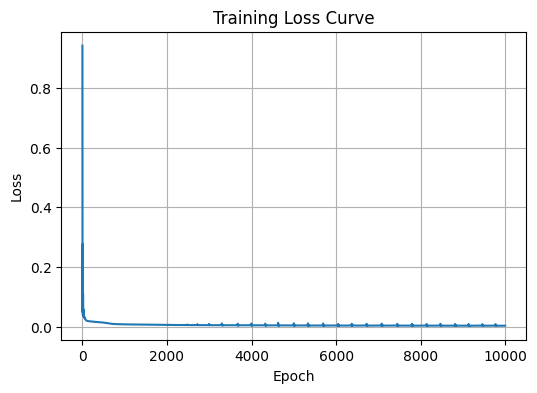

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()



In [ ]:
''' 
epoch가 초반 epoch에 급격히 감소했고 그다음부터는 평평하다 loss가 일정한데 빠르게 잘 완성된듯하다
'''

### 도전 과제 5

실제값(Actual)과 예측값(Predicted)을 Scatter Plot으로 시각화하고 모델 성능을 분석하시오.

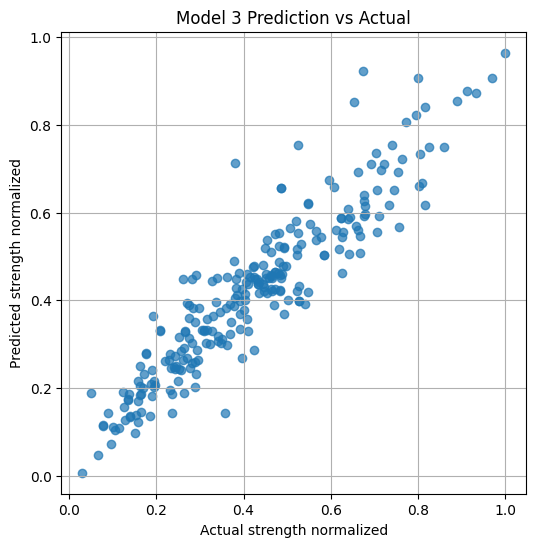

In [61]:
plt.figure(figsize=(6, 6))
plt.scatter(compare_df['actual_strength_norm'], compare_df['pred_model3'], alpha=0.7)
plt.xlabel('Actual strength normalized')
plt.ylabel('Predicted strength normalized')
plt.title('Model 3 Prediction vs Actual')
plt.grid(True)
plt.show()

In [ ]:
''' 
대각선이 잘나왔으니 모델성능이 좋은듯하다
'''